1. import libraries

In [9]:
#import 
%run 00_function.ipynb
# from function import yyplot_k, search_highly_correlated_variables_cv, boruta_cv

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from adjustText import adjust_text
from sklearn.linear_model import ARDRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

2. Setting

In [10]:
#random seed
rseed_cv = 42
rseed_boruta = 1

In [11]:
#select dataset, monomer, descriptors, perc
data_set = "1&2" #1&2
monomer = "St" #St

3. Run model

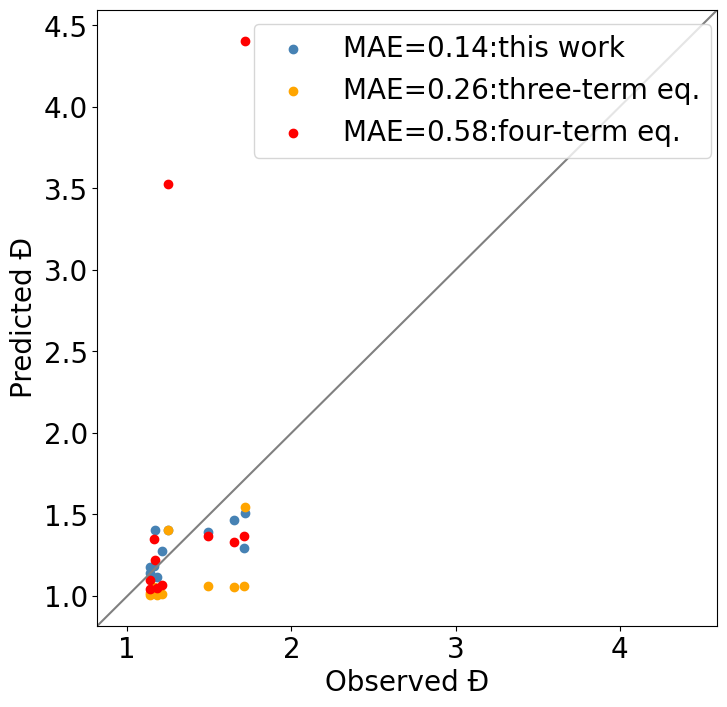

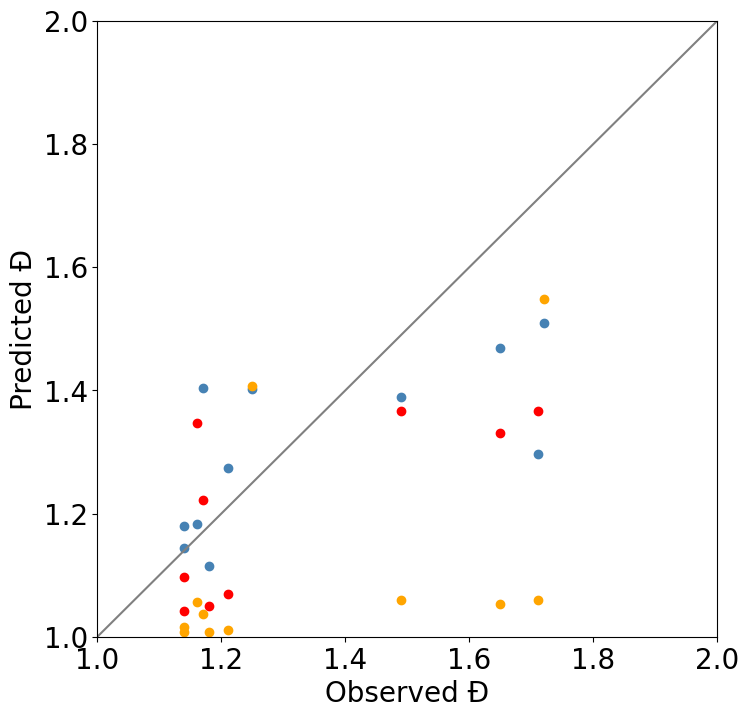

In [15]:
if __name__ == "__main__":
    # file & preprocessing
    try:     
        df = pd.read_excel("../data/comparison_with_explicit_equations/{}_{}_comparison_with_explicit_equations.xlsx".format(data_set, monomer), index_col = 0) #descriptors select
    except ValueError:
        print(f"Sheet '{monomer}' not found. Loading the first sheet instead.")
    
    df_comparison = df.dropna()
    yyplot_comparison(df_comparison.loc[:, "observed_y"] , df_comparison.loc[:, "this work"], df_comparison.loc[:, "three-term eq."], df_comparison.loc[:, "four-term eq."])
    
    MAE_this_work = mean_absolute_error(df_comparison.loc[:, "observed_y"], df_comparison.loc[:, "this work"])
    MAE_three_term = mean_absolute_error(df_comparison.loc[:, "observed_y"], df_comparison.loc[:, "three-term eq."])
    MAE_four_term = mean_absolute_error(df_comparison.loc[:, "observed_y"], df_comparison.loc[:, "four-term eq."])
    
    dirname = "../result/Comparison"
    
    plt.legend(loc='upper left', bbox_to_anchor=(0.23, 1))
    
    plt.savefig(dirname + "/comparison_with_explicit_equations.jpg")
    
    yyplot_comparison_expanded(df_comparison.loc[:, "observed_y"] , df_comparison.loc[:, "this work"], df_comparison.loc[:, "three-term eq."], df_comparison.loc[:, "four-term eq."])
    plt.savefig(dirname + "/comparison_with_explicit_equations_expanded.jpg")